# Libraries & Set up

In [452]:
%run ../../../setup_workspace.py
pi = np.pi

✓ Workspace ready


# Data for Fig3

In [166]:
data_Id13 = pd.read_table('/Users/akmalumarov/Desktop/Comb Paper/Data_Fig3_Id13.csv', sep=';')
data_Id13['x'] *= 10 # A -> nm

data_Id02 = pd.read_table('/Users/akmalumarov/Desktop/Comb Paper/Data_Fig3_Id02.csv', sep=';')

# Functions

In [153]:
def linear(x, k, b):
    return k * x + b

def lin_interp(x, y, i, half):
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    return [lin_interp(x, y, zero_crossings_i[0], half),
            lin_interp(x, y, zero_crossings_i[1], half)]
def FWHM(x, y):
    return half_max_x(x, y)[1] - half_max_x(x, y)[0]

def Gauss(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

# ID13

#### set up

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

#### Plot

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/847318635.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)


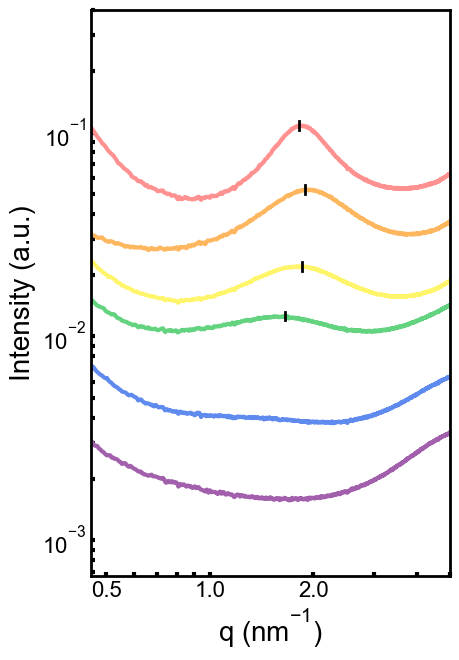

In [155]:
fig, ax = plt.subplots(figsize=(5,7))

k = 1.8
scale = 10
lnwdth = 3

Data = data_Id13

q, I = Data['x'], Data['Ng1'] * scale * k
plt.plot(q, I, linewidth=lnwdth, color='#ff9191')
plt.plot([1.82, 1.82], [max(I[l:r])*1.05, max(I[l:r])/1.05], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x'], Data['Ng2'] * scale 
plt.plot(q, I, linewidth=lnwdth, color='#ffb75f')
plt.plot([1.89, 1.89], [max(I[l:r])*1.05, max(I[l:r])/1.05], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x'], Data['Ng4'] * scale / k / 1.5
plt.plot(q, I, linewidth=lnwdth, color='#fff56a')
plt.plot([1.85, 1.85], [max(I[l:r])*1.05, max(I[l:r])/1.05], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x'], Data['Ng8'] * scale / k ** 2
plt.plot(q, I, linewidth=lnwdth, color='#64d380')
plt.plot([1.65, 1.65], [max(I[l:r])*1.05, max(I[l:r])/1.05], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x'], Data['Ng16'] * scale / k ** 3
plt.plot(q, I, linewidth=lnwdth, color='#5f8aee')

q, I = Data['x'], Data['Ng32'] * scale / k ** 4
plt.plot(q, I, linewidth=lnwdth, color='#a25fac')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.45, 5)
ax.set_ylim(0.666e-3, 0.4)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([0.5, 1, 2, ])

plt.tight_layout()

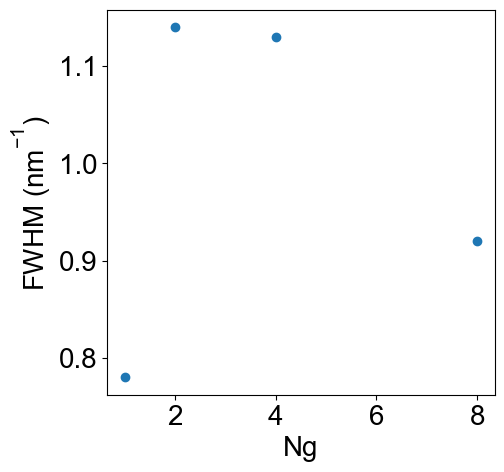

In [131]:
results = pd.DataFrame({'Ng':[1, 2, 4, 8],
                        'q1':[1.82, 1.89, 1.85, 1.65],
                        'FWHM':[0.78, 1.14, 1.13, 0.92]})
plt.figure(figsize=(5,5))

plt.xlabel('Ng')
plt.ylabel('FWHM (nm$^{-1}$)')
#plt.scatter(results['Ng'], results['q1'])
plt.scatter(results['Ng'], results['FWHM'])

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/2607387952.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  p_linear, cov = curve_fit(linear, [q[l], q[r]], [I[l], I[r]], )


(0.0, 0.01)

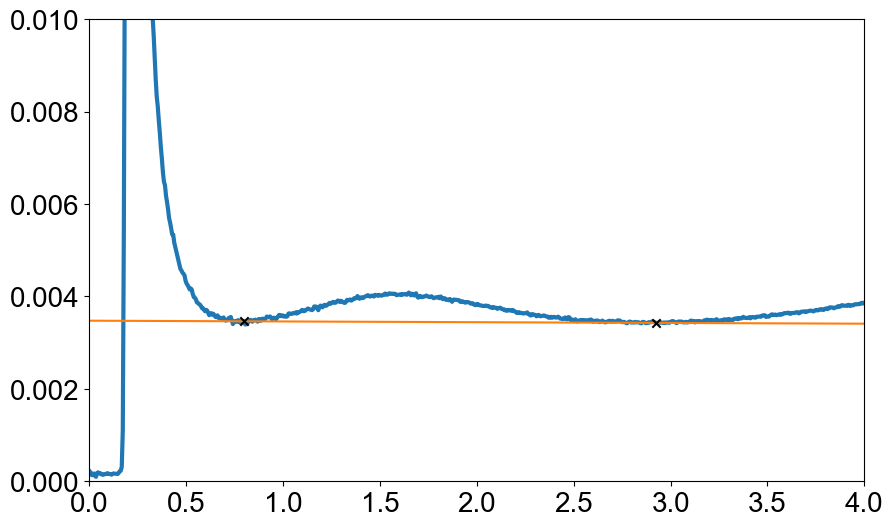

In [143]:
q, I = data['x'], data['Ng8']
plt.plot(q, I,  linewidth=lnwdth)

l, r = 150, 550

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', zorder=100, color='black')
p_linear, cov = curve_fit(linear, [q[l], q[r]], [I[l], I[r]], )
plt.plot(q, linear(q, *p_linear))


plt.xlim(0., 4)
plt.ylim(0, 0.01)

[1.89]
1.14


(np.float64(1.1312370000000005),
 np.float64(1.88805),
 np.float64(0.0023514790867277743),
 np.float64(1.410062),
 np.float64(2.5412990000000004))

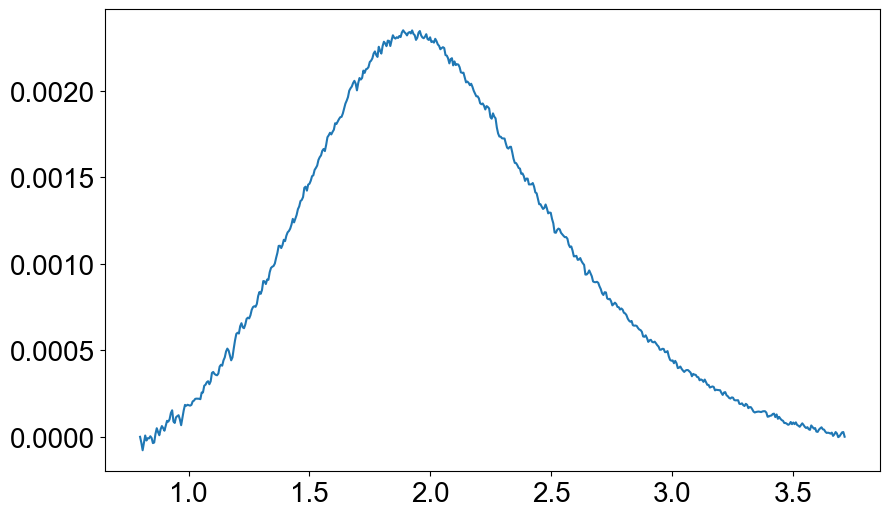

In [142]:
X1 = np.array(q[l:r])
Y1 = np.array(I[l:r] - linear(q[l:r], *p_linear))
plt.plot(X1, Y1)


print(np.round(X1[Y1 == max(Y1)], 2))
print(round(FWHM(X1, Y1), 2))
fwhm_simple(X1,Y1)


[1.65]
0.01


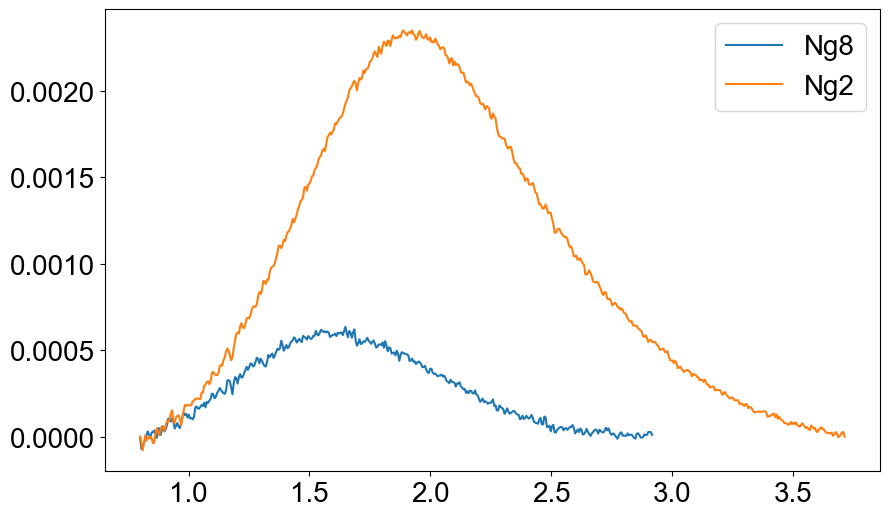

In [147]:
X = np.array(q[l:r])
Y = np.array(I[l:r] - linear(q[l:r], *p_linear))
plt.plot(X, Y, label='Ng8')
plt.plot(X1, Y1, label='Ng2')


print(np.round(X[Y == max(Y)], 2))
print(round(FWHM(X, Y), 2))
fwhm_simple(X,Y)
plt.legend()

In [123]:
import numpy as np

def fwhm_simple(x, y):
    """
    Быстрый расчет FWHM - берем ближайшие точки к половине максимума
    x, y: массивы данных
    Возвращает: FWHM, положение пика, значение пика
    """
    # Находим максимум
    peak_idx = np.argmax(y)
    peak_x = x[peak_idx]
    peak_y = y[peak_idx]
    
    # Половина максимума
    half_max = peak_y / 2
    
    # Левая сторона (до пика)
    left_diff = np.abs(y[:peak_idx] - half_max)
    if len(left_diff) > 0:
        left_idx = np.argmin(left_diff)
        left_x = x[left_idx]
    else:
        left_x = x[0]
    
    # Правая сторона (после пика)
    right_diff = np.abs(y[peak_idx:] - half_max)
    if len(right_diff) > 0:
        right_idx = peak_idx + np.argmin(right_diff)
        right_x = x[right_idx]
    else:
        right_x = x[-1]
    
    # FWHM
    fwhm = right_x - left_x
    
    return fwhm, peak_x, peak_y, left_x, right_x


# ID02

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/2231199298.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)


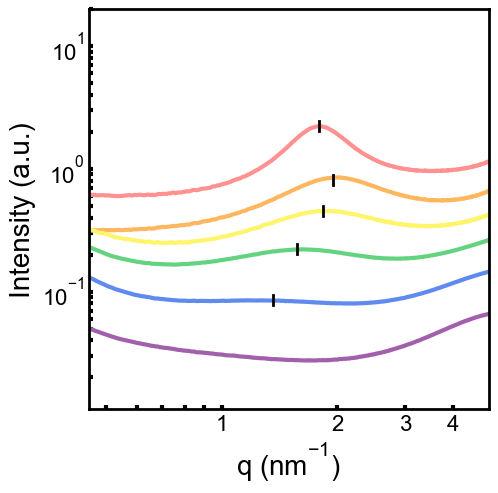

In [387]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_position([0.15, 0.15, 0.8, 0.8])

k = 2.
scale = 100
lnwdth = 3

Data = data_Id02

q, I = Data['x1'], Data['y1'] * scale * k / 1.5
plt.plot(q, I, linewidth=lnwdth, color='#ff9191')
plt.plot([1.79, 1.79], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x2'], Data['y2'] * scale 
plt.plot(q, I, linewidth=lnwdth, color='#ffb75f')
plt.plot([1.95, 1.95], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x4'], Data['y4'] * scale / k 
plt.plot(q, I, linewidth=lnwdth, color='#fff56a')
plt.plot([1.84, 1.84], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x8'], Data['y8'] * scale / k ** 2 / 2
plt.plot(q, I, linewidth=lnwdth, color='#64d380')
plt.plot([1.57, 1.57], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x16'], Data['y16'] * scale / k ** 3 / 2
plt.plot(q, I, linewidth=lnwdth, color='#5f8aee')
plt.plot([1.36, 1.36], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['x32'], Data['y32'] * scale / k ** 4 / 2
plt.plot(q, I, linewidth=lnwdth, color='#a25fac')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.45, 4.95)
ax.set_ylim(1.1e-2, 2e1)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 3,4 
              ])

plt.tight_layout()
ax.set_position([0.15, 0.15, 0.8, 0.8])
plt.savefig('/Users/akmalumarov/Desktop/X_Ray_Scattering_Analysis/projects/Brushes/Comb_Paper/Plots/Fig3_A.png', dpi=300, bbox_inches='tight', transparent=True)

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/755944278.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  p_linear, cov = curve_fit(linear, [q[l], q[r]], [I[l], I[r]], )


(0.0, 0.02)

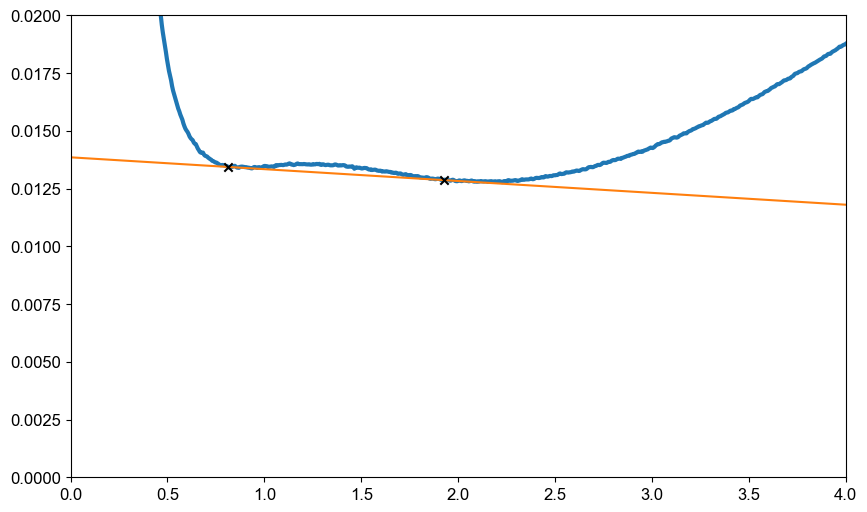

In [532]:
Data = data_Id02
ax.set_position([0.15, 0.15, 0.8, 0.8])

q, I = Data['x16'], Data['y16']
plt.plot(q, I,  linewidth=lnwdth)

l, r = 540, 750

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', zorder=100, color='black')
p_linear, cov = curve_fit(linear, [q[l], q[r]], [I[l], I[r]], )
plt.plot(q, linear(q, *p_linear)*0.999)


plt.xlim(0., 4)
plt.ylim(0, 0.02)

[1.36]
0.0


(np.float64(0.60585),
 np.float64(1.36365),
 np.float64(0.0003767137227264992),
 np.float64(1.07132),
 np.float64(1.67717))

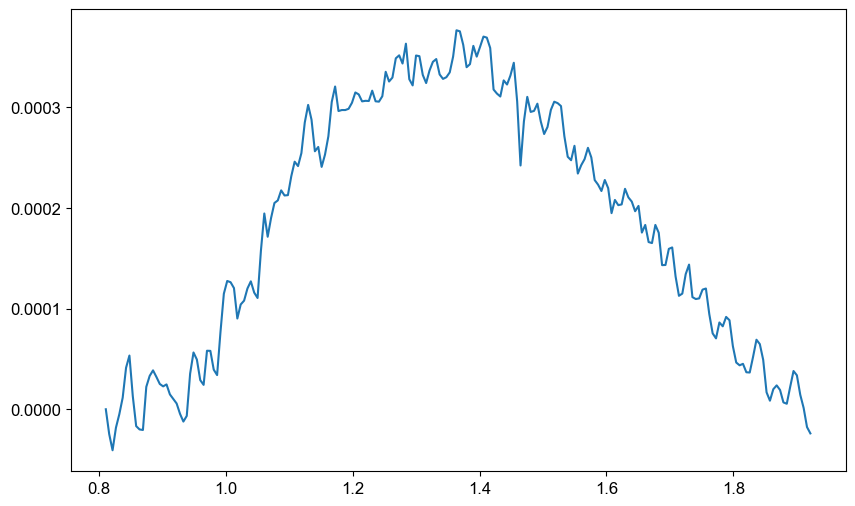

In [533]:
X1 = np.array(q[l:r])
Y1 = np.array(I[l:r] - linear(q[l:r], *p_linear))
plt.plot(X1, Y1)


print(np.round(X1[Y1 == max(Y1)], 2))
print(round(FWHM(X1, Y1), 2))
fwhm_simple(X1,Y1)


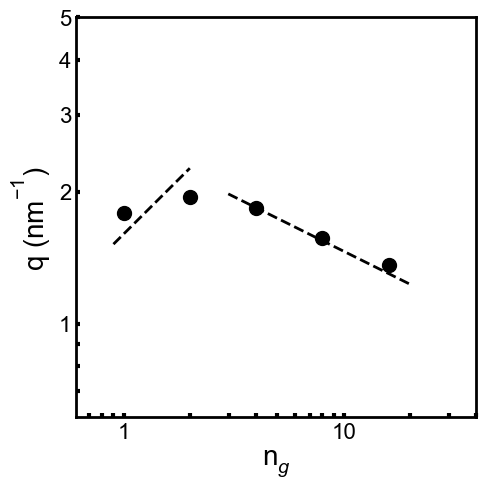

In [534]:
results = pd.DataFrame({'Ng':[1, 2, 4, 8, 16],
                        'q1':[1.79, 1.95, 1.84, 1.57, 1.36],
                        'FWHM':[0.73, 1.2, 1.17, 1.0, 0.7]})

fig, ax = plt.subplots(figsize=(5,5))
ax.set_position([0.15, 0.15, 0.8, 0.8])

# plt.ylabel('q$_1$ (nm$^{-1}$)')
# plt.ylabel('FWHM (nm$^{-1}$)')
plt.scatter(results['Ng'], results['q1'], s=100, color='black')
# plt.scatter(results['Ng'], results['FWHM'], s=100, color='black')

x1 = np.linspace(0.9, 2)
plt.plot(x1, 1.6 * x1 ** 0.5, color='black', linestyle='--', linewidth=2)

x2 = np.linspace(2.99, 20)
plt.plot(x2, 2.6 * x2 ** -0.25, color='black', linestyle='--', linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_xlabel(r'n$_g$', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.61, 40)
ax.set_ylim(0.61, 5)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')


ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 10 ])

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([1, 2, 3, 4, 5, ])

plt.tight_layout()
ax.set_position([0.15, 0.15, 0.8, 0.8])
plt.savefig('/Users/akmalumarov/Desktop/X_Ray_Scattering_Analysis/projects/Brushes/Comb_Paper/Plots/Fig3_B.png', dpi=300, bbox_inches='tight', transparent=True)

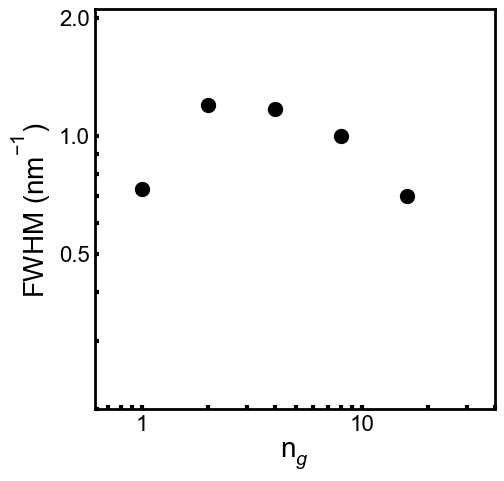

In [535]:
results = pd.DataFrame({'Ng':[1, 2, 4, 8, 16],
                        'q1':[1.79, 1.95, 1.84, 1.57, 1.36],
                        'FWHM':[0.73, 1.2, 1.17, 1.0, 0.7]})

fig, ax = plt.subplots(figsize=(5,5))
ax.set_position([0.15, 0.15, 0.8, 0.8])

# plt.ylabel('q$_1$ (nm$^{-1}$)')
plt.ylabel('FWHM (nm$^{-1}$)')
# plt.scatter(results['Ng'], results['q1'], s=100, color='black')
plt.scatter(results['Ng'], results['FWHM'], s=100, color='black')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'FWHM (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_xlabel(r'n$_g$', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.61, 40)
ax.set_ylim(0.2, 2.1)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')


ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 10 ])

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([ 0.5, 1, 2])

plt.tight_layout()
ax.set_position([0.15, 0.15, 0.8, 0.8])
plt.savefig('/Users/akmalumarov/Desktop/X_Ray_Scattering_Analysis/projects/Brushes/Comb_Paper/Plots/Fig3_C.png', dpi=300, bbox_inches='tight', transparent=True)

## Fig2

In [536]:
from scipy.ndimage import gaussian_filter1d

In [537]:
Data_Fig2 = pd.read_csv('/Users/akmalumarov/Desktop/Comb Paper/Fig2.csv', sep=';', decimal=',')
#

In [538]:
2* pi / 5.89

1.0667547210831216

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/257989072.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)


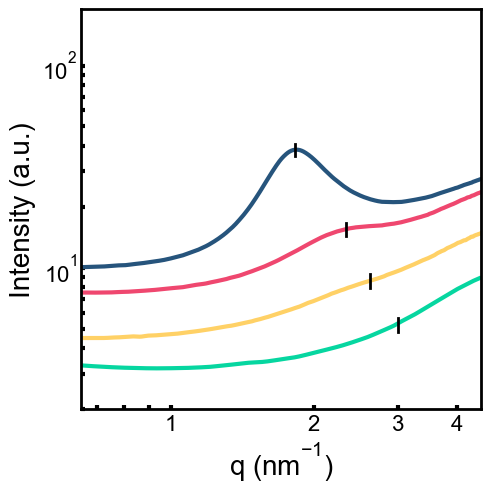

In [539]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_position([0.15, 0.15, 0.8, 0.8])

k = 2.
scale = 1000
lnwdth = 3

Data = Data_Fig2

q, I = Data['q4'], gaussian_filter1d(Data['I4'] * scale * k / 1.5, 5)
plt.plot(q, I, linewidth=lnwdth, color='#26547c')
plt.plot([1.83, 1.83], [max(I[l:r])*1.07, max(I[l:r])/1.07], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q3'], gaussian_filter1d(Data['I3'] * scale, 5)
plt.plot(q, I, linewidth=lnwdth, color='#ef476f')
plt.plot([2.34, 2.34], [max(I[l:r])*1.12, max(I[l:r])/1.03], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q2'], gaussian_filter1d(Data['I2'] * scale / k * 1.2, 5)
plt.plot(q, I, linewidth=lnwdth, color='#ffd166')
plt.plot([2.62, 2.62], [max(I[l:r])*1.25, max(I[l:r])/0.94], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q1'], gaussian_filter1d(Data['I1'] * scale / k ** 2 * 1.8, 15) 
plt.plot(q, I, linewidth=lnwdth, color='#06d6a0')
plt.plot([3.0, 3.0], [max(I[l:r])*1.35, max(I[l:r])*1.15], color='black', linestyle='-', linewidth=2, zorder=10)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.65, 4.5)
ax.set_ylim(2e0, 1.9e2)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 3,4 
              ])

plt.tight_layout()
ax.set_position([0.15, 0.15, 0.8, 0.8])
plt.savefig('/Users/akmalumarov/Desktop/X_Ray_Scattering_Analysis/projects/Brushes/Comb_Paper/Plots/Fig2_A.png', dpi=300, bbox_inches='tight', transparent=True)

/var/folders/x1/4fkphp0x19n84r906qq41l240000gn/T/ipykernel_20428/1030145350.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)


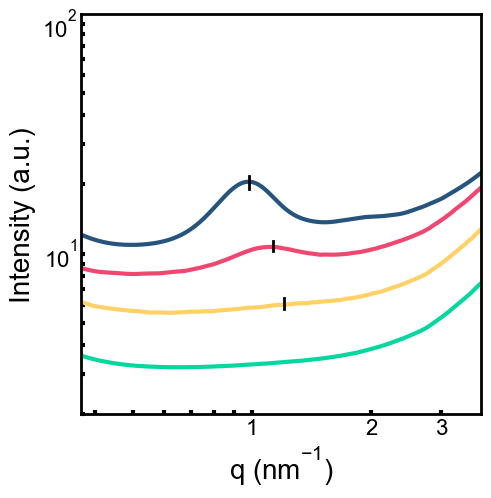

In [542]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_position([0.15, 0.15, 0.8, 0.8])

k = 2.
scale = 1000
lnwdth = 3

Data = Data_Fig2

l, r = 400, 1000
q, I = Data['q6'], gaussian_filter1d(Data['I6'] * scale * k / 1.5, 30)
plt.plot(q, I, linewidth=lnwdth, color='#26547c')
plt.plot([0.98, 0.98], [max(I[l:r])*1.15, max(I[l:r])*1.01], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q7'], gaussian_filter1d(Data['I7'] * scale, 5)
plt.plot(q, I, linewidth=lnwdth, color='#ef476f')
plt.plot([1.13, 1.13], [max(I[l:r])/1.18, max(I[l:r])/1.3], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q8'], gaussian_filter1d(Data['I8'] * scale / k * 1.5, 5)
plt.plot(q, I, linewidth=lnwdth, color='#ffd166')
plt.plot([1.2, 1.2], [max(I[l:r])/1.35, max(I[l:r])/1.5], color='black', linestyle='-', linewidth=2, zorder=10)

q, I = Data['q9'], gaussian_filter1d(Data['I9'] * scale / k ** 2 * 1.8, 15) 
plt.plot(q, I, linewidth=lnwdth, color='#06d6a0')
# plt.plot([1.57, 1.57], [max(I[l:r])*1.1, max(I[l:r])/1.1], color='black', linestyle='-', linewidth=2, zorder=10)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.37, 3.8)
ax.set_ylim(2e0, 1.1e2)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 3])

plt.tight_layout()
ax.set_position([0.15, 0.15, 0.8, 0.8])
plt.savefig('/Users/akmalumarov/Desktop/X_Ray_Scattering_Analysis/projects/Brushes/Comb_Paper/Plots/Fig2_B.png', dpi=300, bbox_inches='tight', transparent=True)